In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

In [2]:
data2010= pd.read_csv(f'../hw3/data/data-2010.csv') 
data2011= pd.read_csv(f'../hw3/data/data-2011.csv')
data2012= pd.read_csv(f'../hw3/data/data-2012.csv')
data2013= pd.read_csv(f'../hw3/data/data-2013.csv')
data2014= pd.read_csv(f'../hw3/data/data-2014.csv')
data2015= pd.read_csv(f'../hw3/data/data-2015.csv')

In [3]:
#merge years
years = range(2010, 2016)
dfs = []
for year in years:
    df = pd.read_csv(f'../hw3/data/data-{year}.csv')
    dfs.append(df)

# Concatenate into one DataFrame
data = pd.concat(dfs, ignore_index=True)

### Question 1

In [4]:
# Market share = average enrolled / average eligibles (from penetration merge)
#data["market_share"] = data["avg_enrolled"] / data["avg_eligibles"]
data["market_share"] = np.where(
    pd.to_numeric(data["avg_enrolled"], errors="coerce") > 0,
    data["avg_enrollment"] / pd.to_numeric(data["avg_enrolled"], errors="coerce"),
    np.nan
)

summary = (
    data.groupby("year")
    .agg(
        mean_star_rating  = ("Star_Rating",    "mean"),
        mean_enrollment   = ("avg_enrollment", "mean"),
        mean_market_share = ("market_share",   "mean"),
        n_plans           = ("contractid",     "count"),
    )
    .reset_index()
    .rename(columns={"year": "Year"})
)

# Format for display
summary["mean_star_rating"]  = summary["mean_star_rating"].round(2)
summary["mean_enrollment"]   = summary["mean_enrollment"].round(0).astype(int)
summary["mean_market_share"] = (summary["mean_market_share"] * 100).round(2).astype(str) + "%"

summary.columns = ["Year", "Mean Star Rating", "Mean Enrollment", "Mean Market Share (%)", "N Plans"]
summary = summary.set_index("Year")

print(summary.to_string())
print()

      Mean Star Rating  Mean Enrollment Mean Market Share (%)  N Plans
Year                                                                  
2010              2.97              256                 6.58%   108222
2011              3.28              343                 8.55%    68003
2012              3.42              377                 8.56%    67246
2013              3.54              396                 8.15%    67835
2014              3.70              437                  8.0%    62344
2015              3.96              470                 7.87%    65499



### Question 2

In [5]:
no_star = data[data["Star_Rating"].isna()]

summary_no_star = (
    no_star.groupby("year")
    .agg(
        mean_enrollment   = ("avg_enrollment", "mean"),
        mean_market_share = ("market_share",   "mean"),
        n_plans           = ("contractid",     "count"),
    )
    .reset_index()
    .rename(columns={"year": "Year"})
)

summary_no_star["mean_enrollment"]   = summary_no_star["mean_enrollment"].round(0).astype(int)
summary_no_star["mean_market_share"] = (summary_no_star["mean_market_share"] * 100).round(2).astype(str) + "%"

summary_no_star.columns = ["Year", "Mean Enrollment", "Mean Market Share (%)", "N Plans (No Star Rating)"]
summary_no_star = summary_no_star.set_index("Year")

print(summary_no_star.to_string())

      Mean Enrollment Mean Market Share (%)  N Plans (No Star Rating)
Year                                                                 
2010              107                 6.73%                     48643
2011              168                  9.0%                     12754
2012              157                 5.24%                      8728
2013              162                 4.67%                      3245
2014              228                 4.06%                      3787
2015              314                 4.05%                      4680


### Question 3

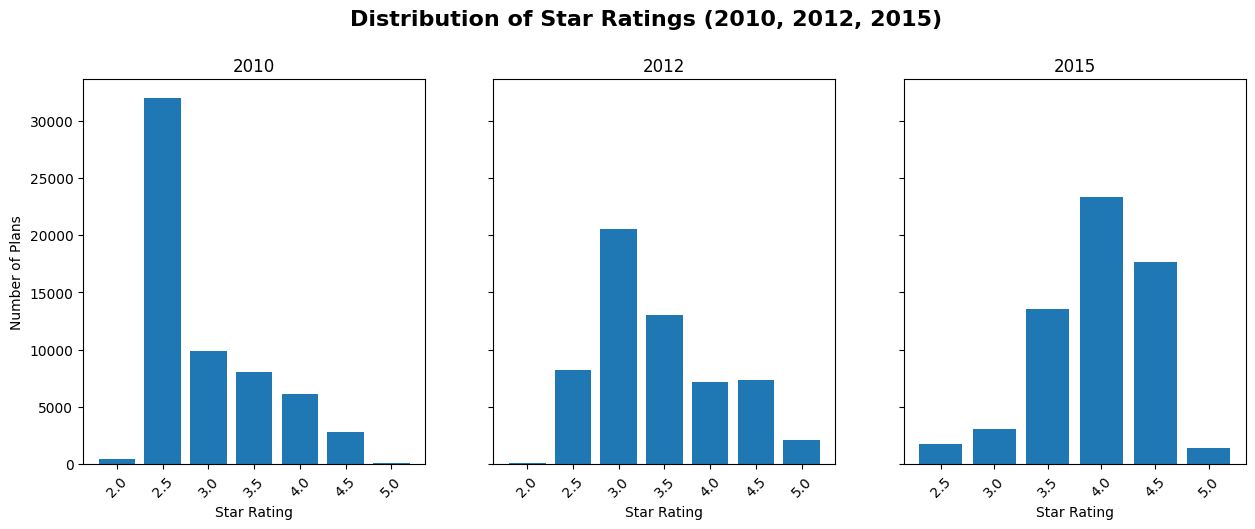

In [6]:
years = [2010, 2012, 2015]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, year in zip(axes, years):
    df_year = data[data["year"] == year]
    
    star_counts = (
        df_year["Star_Rating"]
        .dropna()
        .value_counts()
        .sort_index()
    )
    
    ax.bar(star_counts.index.astype(str), star_counts.values)
    
    ax.set_title(f"{year}", )
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Number of Plans" if year == 2010 else "")
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Distribution of Star Ratings (2010, 2012, 2015)", 
             fontsize=16, fontweight='bold', y=1.02)
# plt.tight_layout()
plt.show()

Interpretation: In 2010, a large proportion of plans concentrated aroudn a star rating of 2.5, and over time, the distribution has normalized and shifted right. In 2012, the largest concentration of star ratings was 3. In 2015, there were no star ratings below 2.5, unlike previously, and we see that the largest concentration of rating scores was 4. This could tell us that either the overall quality of each plan has increased, or that insurance companies have figured out how to game the rating system to have their plans appear higher quality than they may actually be.

### Question 4

In [7]:
YEARS = range(2010, 2016)

def run_ols(df):
    temp = df[["market_share", "Star_Rating"]].dropna()
    
    # Create indicator variables (excluded: <= 2.5)
    temp["star_3"]   = (temp["Star_Rating"] == 3.0).astype(int)
    temp["star_35"]  = (temp["Star_Rating"] == 3.5).astype(int)
    temp["star_4"]   = (temp["Star_Rating"] == 4.0).astype(int)
    temp["star_45"]  = (temp["Star_Rating"] >= 4.5).astype(int)
    
    X = temp[["star_3", "star_35", "star_4", "star_45"]].values
    X = np.column_stack([np.ones(len(X)), X])  # add intercept
    y = temp["market_share"].values
    
    # OLS estimates
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    
    # Standard errors
    y_hat = X @ beta
    resid = y - y_hat
    n, k = X.shape
    s2 = (resid @ resid) / (n - k)
    var_beta = s2 * XtX_inv
    se = np.sqrt(np.diag(var_beta))
    
    # T-stats and p-values
    t_stats = beta / se
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
    
    return beta, se, p_values, n

# Run for each year
results = {}
for year in YEARS:
    df_year = data[data["year"] == year]
    beta, se, p_values, n = run_ols(df_year)
    results[year] = {"beta": beta, "se": se, "p_values": p_values, "n": n}

# Build table
labels = ["Intercept", "Star 3", "Star 3.5", "Star 4", "Star 4.5+"]

def stars(p):
    if p < 0.01:  return "***"
    elif p < 0.05: return "**"
    elif p < 0.1:  return "*"
    return ""

rows = []
for i, label in enumerate(labels):
    # Coefficient row
    coef_row = {"Variable": label}
    for year in YEARS:
        b = results[year]["beta"][i]
        p = results[year]["p_values"][i]
        coef_row[str(year)] = f"{b:.4f}{stars(p)}"
    rows.append(coef_row)
    
    # Standard error row
    se_row = {"Variable": ""}
    for year in YEARS:
        se = results[year]["se"][i]
        se_row[str(year)] = f"({se:.4f})"
    rows.append(se_row)

# Add N row
n_row = {"Variable": "N"}
for year in YEARS:
    n_row[str(year)] = str(results[year]["n"])
rows.append(n_row)

table = pd.DataFrame(rows).set_index("Variable")
table

,2010,2011,2012,2013,2014,2015
Variable,,,,,,
Intercept,0.0634***,0.0813***,0.0876***,0.0488***,0.0606***,0.0606***
,(0.0010),(0.0018),(0.0027),(0.0029),(0.0038),(0.0038)
Star 3,0.0126***,0.0009,0.0202***,0.0653***,0.0450***,0.0271***
,(0.0018),(0.0024),(0.0031),(0.0033),(0.0043),(0.0048)
Star 3.5,0.0005,0.0348***,0.0072**,0.0322***,0.0221***,0.0388***
,(0.0019),(0.0026),(0.0033),(0.0032),(0.0040),(0.0042)
Star 4,-0.0036*,-0.0116***,-0.0228***,0.0257***,0.0233***,0.0115***
,(0.0021),(0.0028),(0.0037),(0.0035),(0.0042),(0.0041)
Star 4.5+,-0.0076***,-0.0221***,-0.0182***,0.0151***,0.0040,0.0233***


### Question 5

In [8]:
measure_cols = [
    'breastcancer_screen', 'rectalcancer_screen', 'cv_diab_cholscreen',
    'glaucoma_test', 'monitoring', 'flu_vaccine', 'pn_vaccine',
    'physical_health', 'mental_health', 'osteo_test', 'physical_monitor',
    'primaryaccess', 'osteo_manage', 'diab_healthy', 'bloodpressure',
    'ra_manage', 'copd_test', 'bladder', 'falling', 'nodelays',
    'doctor_communicate', 'carequickly', 'customer_service',
    'overallrating_care', 'overallrating_plan', 'complaints_plan',
    'appeals_timely', 'appeals_review', 'leave_plan', 'audit_problems',
    'hold_times', 'info_accuracy', 'ttyt_available'
]

data2010["raw_rating"] = data2010[measure_cols].mean(axis=1, skipna=True)

In [9]:
results = []

for star, low in [
    (3.0, 2.75),
    (3.5, 3.25),
    (4.0, 3.75),
    (4.5, 4.25),
    (5.0, 4.75),
]:

    candidates_mask = (
        data2010["raw_rating"].notna()
        & data2010["Star_Rating"].notna()
    )
    candidates = data2010.loc[candidates_mask].copy()

    # score rounding
    match_mask = (
        candidates["raw_rating"].between(low, star)
        & (
            ((candidates["Star_Rating"] == star) &
             (candidates["raw_rating"] >= low) &
            (candidates['raw_rating']< star))
        )
    )
    rounded_up = candidates.loc[match_mask]
    n_rounded_up = len(rounded_up)

    
    print(f"\nStar Rating: {star}")
    print(f"  Plans rounded up into {star} stars:  {n_rounded_up}")


Star Rating: 3.0
  Plans rounded up into 3.0 stars:  3748

Star Rating: 3.5
  Plans rounded up into 3.5 stars:  4444

Star Rating: 4.0
  Plans rounded up into 4.0 stars:  4046

Star Rating: 4.5
  Plans rounded up into 4.5 stars:  771

Star Rating: 5.0
  Plans rounded up into 5.0 stars:  30


### Question 6

In [10]:
data2010["mkt_share"] = np.where(
    pd.to_numeric(data2010["avg_enrolled"], errors="coerce") > 0,
    data2010["avg_enrollment"] / pd.to_numeric(data2010["avg_enrolled"], errors="coerce"),
    np.nan
)

# 3-star vs 2.5-star
ma_rd_3 = data2010[data2010["Star_Rating"].isin([2.5, 3.0])].copy()
ma_rd_3["score"]       = ma_rd_3["raw_rating"] - 2.75
ma_rd_3["treat"]       = (ma_rd_3["score"] >= 0).astype(int)
ma_rd_3["score_treat"] = ma_rd_3["score"] * ma_rd_3["treat"]
ma_rd_3["window"]      = ma_rd_3["score"].between(-0.125, 0.125)
ma_rd_3 = ma_rd_3.dropna(subset=["mkt_share", "score"])

star3_1 = smf.ols("mkt_share ~ score + treat", data=ma_rd_3).fit()
star3_2 = smf.ols("mkt_share ~ score + treat", data=ma_rd_3[ma_rd_3["window"]]).fit()
star3_3 = smf.ols("mkt_share ~ score + treat + score_treat", data=ma_rd_3[ma_rd_3["window"]]).fit()

# 3.5-star vs 3-star
ma_rd_35 = data2010[data2010["Star_Rating"].isin([3.0, 3.5])].copy()
ma_rd_35["score"]       = ma_rd_35["raw_rating"] - 3.25
ma_rd_35["treat"]       = (ma_rd_35["score"] >= 0).astype(int)
ma_rd_35["score_treat"] = ma_rd_35["score"] * ma_rd_35["treat"]
ma_rd_35["window"]      = ma_rd_35["score"].between(-0.125, 0.125)
ma_rd_35 = ma_rd_35.dropna(subset=["mkt_share", "score"])

star35_1 = smf.ols("mkt_share ~ score + treat", data=ma_rd_35).fit()
star35_2 = smf.ols("mkt_share ~ score + treat", data=ma_rd_35[ma_rd_35["window"]]).fit()
star35_3 = smf.ols("mkt_share ~ score + treat + score_treat", data=ma_rd_35[ma_rd_35["window"]]).fit()

# Summary table
from statsmodels.iolib.summary2 import summary_col

table = summary_col(
    [star3_3, star35_3],
    model_names=["3-star", "3.5-star"],
    stars=True,
    regressor_order=["Intercept", "treat", "score", "score_treat"],
    drop_omitted=True
)
print(table)


                 3-star    3.5-star 
------------------------------------
Intercept      0.0163***  0.1023*** 
               (0.0034)   (0.0077)  
treat          0.0546***  -0.0395***
               (0.0083)   (0.0096)  
score          -0.7403*** 0.4167*** 
               (0.0415)   (0.0845)  
score_treat    0.9580***  -0.4674***
               (0.1089)   (0.1114)  
R-squared      0.0595     0.0148    
R-squared Adj. 0.0590     0.0132    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### Question 7

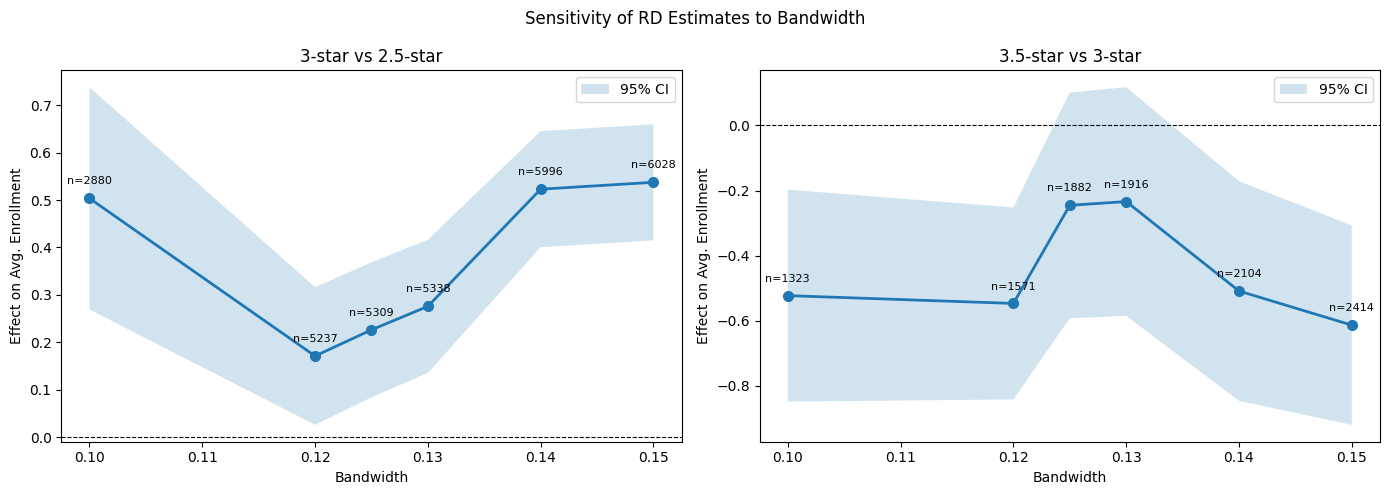

In [11]:
import matplotlib.pyplot as plt
import numpy as np

bws = [0.10, 0.12, 0.125, 0.13, 0.14, 0.15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (star_vals, midpoint, label) in zip(axes, [
    ([2.5, 3.0], 2.75, "3-star vs 2.5-star"),
    ([3.0, 3.5], 3.25, "3.5-star vs 3-star"),
]):
    candidates = data2010[data2010["Star_Rating"].isin(star_vals)].copy()
    candidates["score"]       = candidates["raw_rating"] - midpoint
    candidates["treat"]       = (candidates["score"] >= 0).astype(int)
    candidates["score_treat"] = candidates["score"] * candidates["treat"]
    candidates = candidates.dropna(subset=["avg_enrollment", "score"])

    coefs, ses, ns = [], [], []
    for bw in bws:
        sample = candidates[candidates["score"].between(-bw, bw)]
        m = smf.ols("avg_enrollment ~ score + treat + score_treat", data=sample).fit()
        coefs.append(float(m.params["treat"]))
        ses.append(float(m.bse["treat"]))
        ns.append(int(m.nobs))

    coefs = np.array(coefs)/1000
    ses   = np.array(ses)/1000

    ax.plot(bws, coefs, 'o-', linewidth=2, markersize=7)
    ax.fill_between(bws,
                    coefs - 1.96 * ses,
                    coefs + 1.96 * ses,
                    alpha=0.2, label="95% CI")
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel("Bandwidth")
    ax.set_ylabel("Effect on Avg. Enrollment")
    ax.legend()

    for bw, coef, n in zip(bws, coefs, ns):
        ax.annotate(f"n={n}", (bw, coef),
                    textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=8)

fig.suptitle("Sensitivity of RD Estimates to Bandwidth")
plt.tight_layout()
plt.show()

Interpretation: We observed almost opposite effects when comparing the various effects across bandwidths for 3 vs. 2.5 star and 3 vs. 3.5 star ratings. For the effects for 3 vs. 2.5 stars, the effect stays above zero and dips at bandwidth =.12. On the other hand, in 3.5 vs. 3 stars, we see that the effect is generally below zero, meaning it is less stable, and has an increase at bandwidth =.13. 

### Question 8

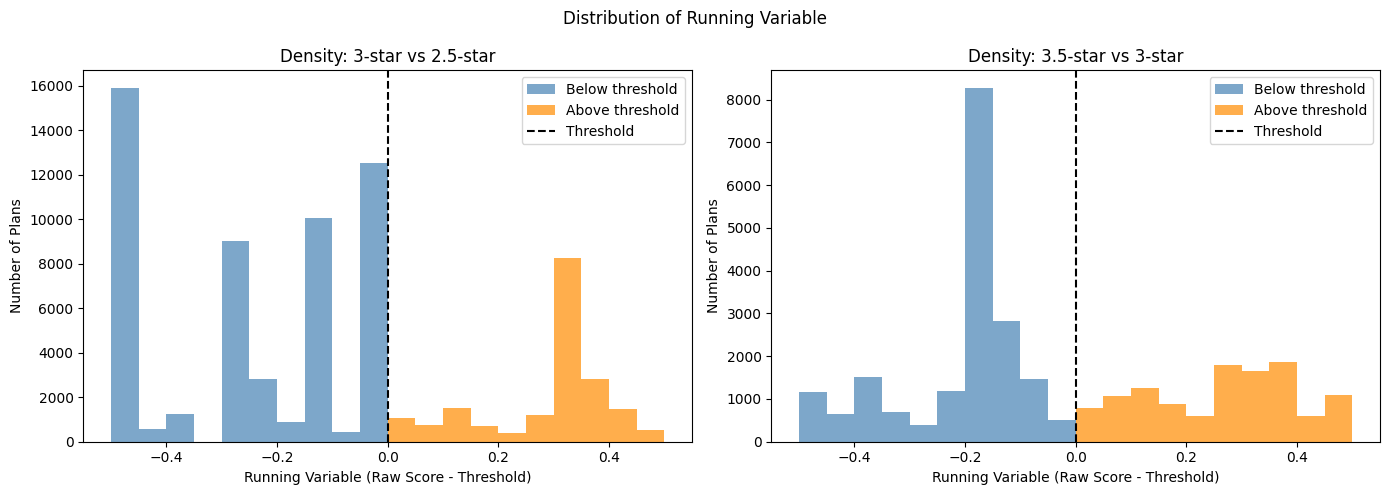

In [12]:
thresholds = {
    "3-star vs 2.5-star": 2.75,
    "3.5-star vs 3-star": 3.25,
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, thresh) in zip(axes, thresholds.items()):
    bw = 0.5
    temp = data2010.copy()
    temp["score"] = temp["raw_rating"] - thresh
    temp = temp[(temp["score"] >= -bw) & (temp["score"] <= bw)].dropna(subset=["score"])

    bins = np.arange(-bw, bw + 0.05, 0.05)
    below = temp[temp["score"] < 0]["score"]
    above = temp[temp["score"] >= 0]["score"]

    ax.hist(below, bins=bins, color="steelblue", alpha=0.7, label="Below threshold")
    ax.hist(above, bins=bins, color="darkorange", alpha=0.7, label="Above threshold")
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label="Threshold")
    ax.set_title(f"Density: {label}")
    ax.set_xlabel("Running Variable (Raw Score - Threshold)")
    ax.set_ylabel("Number of Plans")
    ax.legend()

fig.suptitle("Distribution of Running Variable")
plt.tight_layout()
plt.show()

It seems like there is a larger proportion of plans that fall below the threshold compared to above for both 3 vs. 2.5 star and 3 vs. 3.5 star ratings. That means plans are more likely to be rounded down based on their raw scores, which I did not expect since I thought it would be likely that insurance companies would try to game the scoring system. Because 2010 was the first year this star rating system was in place, it makes more sense that companies' scores did not concentrate just above the threshold.

### Question 9

In [15]:
bw = 0.125

data2010["is_hmo"]   = (data2010["plan_type"].str.upper().str.contains("HMO|CCP|LOCAL", na=False)).astype(int)
data2010["is_partd"] = (data2010["partd"] == "Yes").astype(int)

rows = []

for label, star_vals, midpoint in [
    ("3-star vs 2.5-star", [2.5, 3.0], 2.75),
    ("3.5-star vs 3-star", [3.0, 3.5], 3.25),
]:
    sample = data2010[data2010["Star_Rating"].isin(star_vals)].copy()
    sample["score"] = sample["raw_rating"] - midpoint
    sample = sample[sample["score"].between(-bw, bw)].dropna(subset=["score"])

    below = sample[sample["score"] < 0]
    above = sample[sample["score"] >= 0]

    for var, var_label in [("is_hmo", "HMO"), ("is_partd", "Part D")]:
        t, p = stats.ttest_ind(above[var].dropna(), below[var].dropna())
        rows.append({
            "Threshold":    label,
            "Characteristic": var_label,
            "Mean Below":   f"{below[var].mean():.3f}",
            "Mean Above":   f"{above[var].mean():.3f}",
            "Difference":   f"{above[var].mean() - below[var].mean():.3f}",
            "P-value":      f"{p:.3f}",
            "N Below":      len(below),
            "N Above":      len(above),
        })

table = pd.DataFrame(rows)
print(table.to_string(index=False))

         Threshold Characteristic Mean Below Mean Above Difference P-value  N Below  N Above
3-star vs 2.5-star            HMO      0.034      0.707      0.672   0.000    19313     1951
3-star vs 2.5-star         Part D      0.523      0.906      0.383   0.000    19313     1951
3.5-star vs 3-star            HMO      1.000      0.844     -0.156   0.000     3127     2396
3.5-star vs 3-star         Part D      0.928      0.813     -0.115   0.000     3127     2396


/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


### Question 10

As star rating increases, we would expect enrollments increase. Through this data analysis, we saw how frequently plan ratings are rounded up into the next-up group by .5 stars, what distribution of plans fall above or below this rounding threshold, and how different characteristics and star ratings impact enrollments. We see that less and less plans are rounded up into the next group as star rating increases. We also observed that the market share for plans rounded as 3-star was greater than plans rouneded into -3.5 star, which is not what we might expect. We even observed that there was a much greater distribution of plans that fell just under thresholds to be rounded up, which is again, opposite of what we might anticipate. Lastly, we found that plan characteristics such as those of HMO and Part D status do have different distributions depending on where they fall according to the thresholds between 2.5 and 3, and 3 and 3.5 stars. Plans that are both rounded up or down into 3-star ratings are more likely to be HMO or Part D plans compared to the rating groups just above or below. Perhaps this signls some sort of correlation between what plans are offered with specific characteristics depending on their star rating. 